# Create positions from tissue boundaries

Builds the FOV scanning positions for one or more tissue sections on a coverslip.

**Layouts** (auto-detected from the filenames in `positions/`):
- **multi**  — `tissue_{t}_boundary_positions_{b}.txt`: several tissue sections,
  each possibly split across several boundary files.
- **single** — `boundary_positions_{b}.txt`: one tissue, several boundaries.
- **legacy** — a lone `boundary_positions.txt`: one boundary (original behaviour).

**Transit FOVs.** Boundaries are visited in order (sorted by tissue then
boundary). Between consecutive boundaries — and wrapping the last back to the
first — a **transit** segment moves the stage smoothly: FOVs on the straight line
from the last FOV of one boundary to the first FOV of the next, spaced ~2× the
grid step. Transit FOVs are imaged with blank frames at the bead focus (the
`hal-config-*-transit-*` from notebook 01).

**Outputs** (written to `positions/`, with `SAMPLE = SAMPLE_DIR.name`):
- per-segment files referenced by Dave: `positions_{SAMPLE}_{label}.txt`
  (`label` = `T{t}B{b}` / `B{b}`) and `positions_{SAMPLE}_transit_{k}.txt`
- per-tissue FOV-only files (no transit): `positions_{SAMPLE}_T{t}.txt`
  (multi) or `positions_{SAMPLE}.txt` (single/legacy)

It also creates the `data/` subfolders for the layout (`mosaic10x`, and either
`tissue_{t}/{cells,hybs,transit}` or top-level `{cells,hybs,transit}`).

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MERCI_DIR  = Path(os.getcwd()).parent.parent.parent.parent   # MERci/ (notebook lives in MERci/notebooks/prepare_imaging/<variant>/<acquisition>/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root, e.g. LT048_sample_18/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.io             import save_positions_array
from MERci.acquisition.positions import (
    discover_boundary_files, resolve_boundary_dir, load_boundary_polygon, load_hole_polygons,
    build_boundary_path, create_transit_path, get_path_stats,
)

In [2]:
POSITIONS_DIR = SAMPLE_DIR / "positions"
DATA_DIR      = SAMPLE_DIR / "data"
POSITIONS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_NAME = SAMPLE_DIR.name

# ── Grid / FOV geometry ──────────────────────────────────────────────────
pixel_size_um        = 0.0878 # 6.5 um pixel / (60x objective * 0.9 tube lens * 0.9 camera sensor)
image_size_px        = 2304
non_overlap_fraction = 0.9

step_size_um = pixel_size_um * image_size_px * non_overlap_fraction
fov_size_um  = pixel_size_um * image_size_px

# ── Scanning / transit options ───────────────────────────────────────────
SCAN_DIRECTION       = "vertical"   # boustrophedon direction within each boundary
TRANSIT_SPACING      = 2.0          # transit FOV spacing as a multiple of step_size

# ── Discover the boundary layout ─────────────────────────────────────────
# If positions/ has no boundary files yet (e.g. a fresh experiment), fall back to
# a bundled EXAMPLE dataset under MERci/data/positions/examples/ so the notebook
# can still be run and tested. EXAMPLE_LAYOUT selects which example set to use.
EXAMPLE_LAYOUT = "multi"     # "legacy" | "single" | "multi"
EXAMPLE_ROOT   = MERCI_DIR / "data" / "positions" / "examples"
BOUNDARY_DIR, USING_EXAMPLE = resolve_boundary_dir(POSITIONS_DIR, EXAMPLE_ROOT, EXAMPLE_LAYOUT)
if USING_EXAMPLE:
    # positions/ has no boundary files: copy the example boundary + hole inputs
    # into it so the experiment folder is self-contained and notebooks 03/04
    # (which read positions/ directly) find them. Idempotent: once copied,
    # resolve_boundary_dir returns positions/ and this branch is skipped.
    import shutil
    copied = [f.name for f in sorted(BOUNDARY_DIR.glob("*.txt"))]
    for fname in copied:
        shutil.copy2(BOUNDARY_DIR / fname, POSITIONS_DIR / fname)
    print(f"WARNING: no boundary files in {POSITIONS_DIR};")
    print(f"         copied {len(copied)} example input(s) from '{EXAMPLE_LAYOUT}' -> positions/: {copied}\n")
    BOUNDARY_DIR = POSITIONS_DIR

boundaries, MODE = discover_boundary_files(BOUNDARY_DIR)
tissues          = sorted({b.tissue for b in boundaries})
n_boundaries     = len(boundaries)
# Transit segments connect consecutive boundaries and wrap the last back to the
# first, so there are as many transits as boundaries — unless there is only one.
n_transits       = n_boundaries if n_boundaries > 1 else 0

print(f"SAMPLE_DIR    : {SAMPLE_DIR}")
print(f"SAMPLE_NAME   : {SAMPLE_NAME}")
print(f"POSITIONS_DIR : {POSITIONS_DIR}")
print(f"Step size     : {step_size_um:.1f} um")
print(f"FOV size      : {fov_size_um:.1f} um")
print(f"\nLayout mode   : {MODE}")
print(f"Tissues       : {tissues}")
print(f"Boundaries ({n_boundaries}) in acquisition order:")
for b in boundaries:
    print(f"  {b.label or '(single)':8s}  <- {b.path.name}")
print(f"Transit segments: {n_transits}")

         copied 4 example input(s) from 'multi' -> positions/: ['tissue_1_boundary_positions_1.txt', 'tissue_1_boundary_positions_2.txt', 'tissue_2_boundary_positions_1.txt', 'tissue_2_boundary_positions_2.txt']

SAMPLE_DIR    : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time
SAMPLE_NAME   : 251225_LT027_saving_time
POSITIONS_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\positions
Step size     : 182.1 um
FOV size      : 202.3 um

Layout mode   : multi
Tissues       : [1, 2]
Boundaries (4) in acquisition order:
  T1B1      <- tissue_1_boundary_positions_1.txt
  T1B2      <- tissue_1_boundary_positions_2.txt
  T2B1      <- tissue_2_boundary_positions_1.txt
  T2B2      <- tissue_2_boundary_positions_2.txt
Transit segments: 4


In [3]:
# ── Load boundaries + holes, build per-boundary FOV paths ────────────────
# Holes are global: every hole*.txt applies to every boundary.
holes = load_hole_polygons(BOUNDARY_DIR)
print(f"Loaded {len(holes)} hole polygon(s) (applied to all boundaries)")

boundary_polys = [load_boundary_polygon(b.path) for b in boundaries]
boundary_paths = [
    build_boundary_path(
        poly, holes, step_size_um, fov_size_um,
        direction   = SCAN_DIRECTION,
        # Legacy single-boundary keeps the original loop-closure; in the
        # multi-boundary layout the transit segments handle travel between
        # boundaries, so no per-boundary closure is applied.
        return_side = ("top" if MODE == "legacy" else None),
    )
    for poly in boundary_polys
]
for spec, path in zip(boundaries, boundary_paths):
    if len(path) == 0:
        raise ValueError(
            f"Boundary {spec.label or spec.path.name} produced 0 FOVs — "
            f"check the boundary file and grid geometry."
        )

# ── Build transit segments: boundary k -> boundary k+1 (wrap last -> first) ─
transit_paths = []
if n_transits:
    for k in range(n_boundaries):
        a      = boundary_paths[k][-1]                       # last FOV of boundary k
        b_next = boundary_paths[(k + 1) % n_boundaries][0]   # first FOV of the next
        transit_paths.append(
            create_transit_path(a, b_next, step_size_um, TRANSIT_SPACING)
        )

# ── Assemble the ordered segment list: boundary_k, transit_k, boundary_k+1… ─
# A transit is attributed to the tissue of the boundary it departs from (its
# files go to that tissue's data/transit folder).
segments = []
for k, (spec, path) in enumerate(zip(boundaries, boundary_paths)):
    segments.append({"kind": "boundary", "tissue": spec.tissue,
                     "label": spec.label, "coords": path})
    if n_transits:
        segments.append({"kind": "transit", "tissue": spec.tissue,
                         "label": f"transit_{k + 1}", "coords": transit_paths[k]})

print(f"\n{n_boundaries} boundary segments + {n_transits} transit segments:")
for spec, path in zip(boundaries, boundary_paths):
    print(f"  {spec.label or '(single)':10s}: {len(path)} FOVs")
for k in range(n_transits):
    print(f"  transit_{k + 1:<3d}: {len(transit_paths[k])} FOVs")

Loaded 0 hole polygon(s) (applied to all boundaries)

4 boundary segments + 4 transit segments:
  T1B1      : 64 FOVs
  T1B2      : 64 FOVs
  T2B1      : 64 FOVs
  T2B2      : 64 FOVs
  transit_1  : 3 FOVs
  transit_2  : 16 FOVs
  transit_3  : 3 FOVs
  transit_4  : 15 FOVs


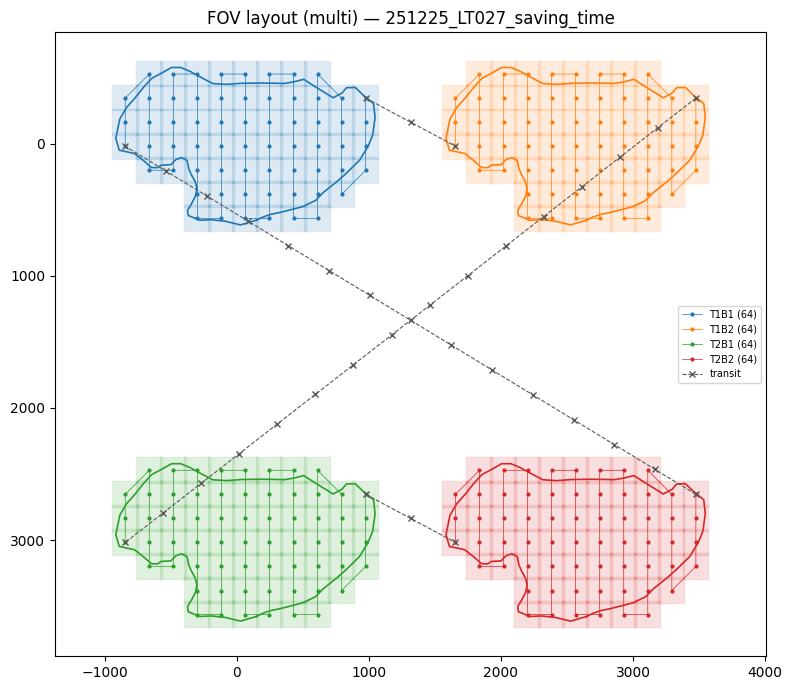

In [4]:
# ── Overview plot: all boundaries, their FOVs, and the transit segments ──
half   = fov_size_um / 2
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 7))
for i, (spec, poly, path) in enumerate(zip(boundaries, boundary_polys, boundary_paths)):
    c = colors[i % len(colors)]
    ax.plot(*poly.exterior.xy, "-", lw=1.2, color=c)
    for x, y in path:
        ax.add_patch(mpatches.Rectangle((x - half, y - half), fov_size_um, fov_size_um,
                                        lw=0.3, edgecolor=c, facecolor=c, alpha=0.15))
    ax.plot(path[:, 0], path[:, 1], "-o", ms=2, lw=0.5, color=c,
            label=f"{spec.label or 'boundary'} ({len(path)})")

for hole in holes:
    ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
    ax.plot(*hole.exterior.xy, "k--", lw=0.8)

for k, tr in enumerate(transit_paths):
    ax.plot(tr[:, 0], tr[:, 1], "--x", ms=4, lw=0.8, color="0.35",
            label="transit" if k == 0 else None)

ax.invert_yaxis(); ax.axis("equal")
ax.legend(fontsize=7, loc="best")
plt.title(f"FOV layout ({MODE}) — {SAMPLE_NAME}")
plt.tight_layout()
fig.savefig(POSITIONS_DIR / f"fov_layout_{SAMPLE_NAME}.png", dpi=150)
plt.show()

In [5]:
# ── Full-sequence path statistics (in acquisition order) ─────────────────
full_path             = np.concatenate([s["coords"] for s in segments], axis=0)
total_um, max_step_um = get_path_stats(full_path)
n_bd_fovs = sum(len(p) for p in boundary_paths)
n_tr_fovs = sum(len(t) for t in transit_paths)

print(f"FOVs in acquisition order : {len(full_path)}  "
      f"({n_bd_fovs} boundary + {n_tr_fovs} transit)")
print(f"Full path length          : {total_um / 1000:.1f} mm")
print(f"Max single step           : {max_step_um:.0f} um  "
      f"(transit target ~{TRANSIT_SPACING * step_size_um:.0f} um)")

FOVs in acquisition order : 293  (256 boundary + 37 transit)
Full path length          : 58.9 mm
Max single step           : 385 um  (transit target ~364 um)


In [6]:
# ── Create data/ subfolders for this layout ──────────────────────────────
(DATA_DIR / "mosaic10x").mkdir(parents=True, exist_ok=True)
if MODE == "multi":
    for t in tissues:
        for sub in ("cells", "hybs", "transit"):
            (DATA_DIR / f"tissue_{t}" / sub).mkdir(parents=True, exist_ok=True)
else:  # single / legacy: top-level cells/hybs (+ transit if there are transits)
    for sub in ("cells", "hybs"):
        (DATA_DIR / sub).mkdir(parents=True, exist_ok=True)
    if n_transits:
        (DATA_DIR / "transit").mkdir(parents=True, exist_ok=True)
print(f"Data folders created under {DATA_DIR}")

# ── Write per-segment positions files (referenced by Dave) ───────────────
# Skipped for the legacy single boundary (empty label) — its FOVs are written
# below as the aggregate positions_{SAMPLE}.txt.
written = []
for seg in segments:
    if not seg["label"]:
        continue
    fname = f"positions_{SAMPLE_NAME}_{seg['label']}.txt"
    save_positions_array(seg["coords"], POSITIONS_DIR / fname)
    written.append(fname)

# ── Write per-tissue FOV-only files (boundary FOVs only, no transit) ──────
if MODE == "multi":
    for t in tissues:
        coords = np.concatenate(
            [p for spec, p in zip(boundaries, boundary_paths) if spec.tissue == t], axis=0)
        fname = f"positions_{SAMPLE_NAME}_T{t}.txt"
        save_positions_array(coords, POSITIONS_DIR / fname)
        written.append(fname)
else:  # single / legacy: one aggregate file of all boundary FOVs
    coords = np.concatenate(boundary_paths, axis=0)
    fname  = f"positions_{SAMPLE_NAME}.txt"
    save_positions_array(coords, POSITIONS_DIR / fname)
    written.append(fname)

print(f"\nWrote {len(written)} positions file(s) to {POSITIONS_DIR}:")
for f in written:
    print(f"  {f}")

Data folders created under c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\data

Wrote 10 positions file(s) to c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\positions:
  positions_251225_LT027_saving_time_T1B1.txt
  positions_251225_LT027_saving_time_transit_1.txt
  positions_251225_LT027_saving_time_T1B2.txt
  positions_251225_LT027_saving_time_transit_2.txt
  positions_251225_LT027_saving_time_T2B1.txt
  positions_251225_LT027_saving_time_transit_3.txt
  positions_251225_LT027_saving_time_T2B2.txt
  positions_251225_LT027_saving_time_transit_4.txt
  positions_251225_LT027_saving_time_T1.txt
  positions_251225_LT027_saving_time_T2.txt
